# Ottimizzazione UMAP e HDBSCAN (Dataset 1.75M)
Questo notebook esegue il clustering definitivo sul dataset di produzione. Includiamo anche i grafici di topologia.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from scipy.spatial.distance import cdist
from scipy.special import softmax

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.clustering_hdbscan import run_umap_hdbscan

EMBEDDINGS_PATH = PROJECT_ROOT / "data/embeddings/email_embeddings.npy"
INDEX_PATH = PROJECT_ROOT / "data/metadata/email_embedding_index.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data/processed"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

## 1. Caricamento Dati
Carichiamo la matrice colossale da 2.6GB generata dalla pipeline BGE-Small.

In [2]:
print("Caricamento embeddings in corso...")
embeddings = np.load(EMBEDDINGS_PATH)
index_df = pd.read_parquet(INDEX_PATH)
print(f"Caricati {embeddings.shape[0]} vettori di dimensione {embeddings.shape[1]}")

Caricamento embeddings in corso...
Caricati 1757624 vettori di dimensione 384


## 2. Esecuzione UMAP e HDBSCAN
Fase di Sub-sampling e Inferenza su 1.75 Milioni di vettori. (Richiede ~30 minuti)

In [3]:
labels, probabilities, clusterer, reduced_embeddings = run_umap_hdbscan(
    embeddings=embeddings,
    n_neighbors=30,
    n_components=5,
    min_cluster_size=15,
    min_samples=3,
    cluster_selection_method="leaf",
    sample_size=100000
)

2026-06-18 10:09:36,451 - INFO - Dataset enorme (1757624 vettori). Eseguo sub-sampling a 100000 per addestramento UMAP e HDBSCAN.
2026-06-18 10:09:36,493 - INFO - Avvio addestramento UMAP su 100000 vettori da 384 dimensioni...
2026-06-18 10:09:36,493 - INFO - Parametri UMAP: n_neighbors=30, n_components=5, min_dist=0.01
/home/filippo/Scrivania/pizza-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-06-18 10:10:56,552 - INFO - UMAP addestrato. Nuova dimensionalità: (100000, 5)
2026-06-18 10:10:56,553 - INFO - Avvio addestramento HDBSCAN sui vettori ridotti...
2026-06-18 10:10:56,553 - INFO - Parametri HDBSCAN: min_cluster_size=15, min_samples=3, method='leaf'
2026-06-18 10:10:59,960 - INFO - Addestramento HDBSCAN completato sul campione. Cluster trovati: 923, Rumore: 65940
2026-06-18 10:10:59,960 - INFO - Proiezione dei restanti 1757624 vettori nei cluster...
2026-

## 3. Visualizzazione: Costellazione UMAP 2D
Disegniamo i primi due assi del nuovo spazio latente usando un campione di 50.000 punti per evitare crash grafici.

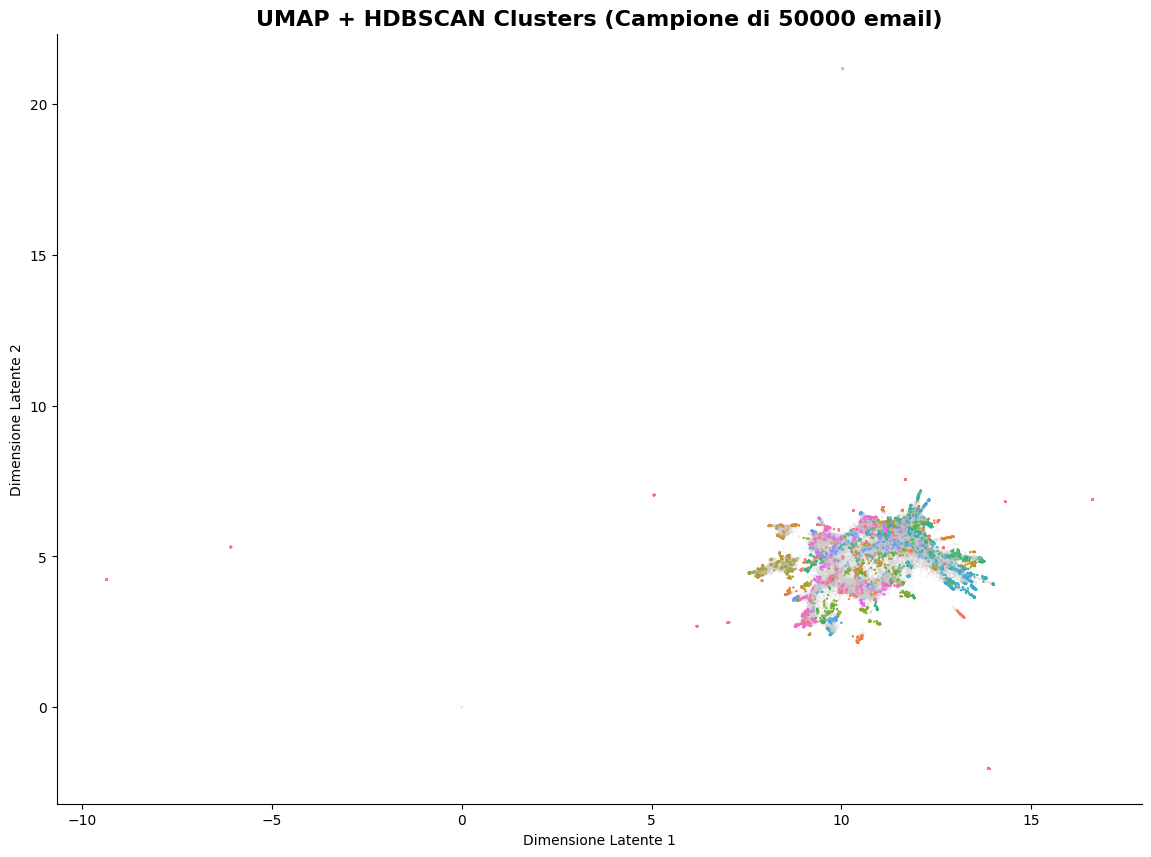

In [4]:
sample_size = 50000
np.random.seed(42)

if reduced_embeddings.shape[0] > sample_size:
    indices = np.random.choice(reduced_embeddings.shape[0], sample_size, replace=False)
    plot_data = reduced_embeddings[indices]
    plot_labels = labels[indices]
else:
    plot_data = reduced_embeddings
    plot_labels = labels

unique_labels = np.unique(plot_labels)
num_colors = len(unique_labels) - (1 if -1 in unique_labels else 0)
palette = sns.color_palette("husl", num_colors)

color_map = {-1: (0.8, 0.8, 0.8, 0.2)}
for i, lbl in enumerate(l for l in unique_labels if l != -1):
    r, g, b = palette[i]
    color_map[lbl] = (r, g, b, 1.0)

colors = [color_map[l] for l in plot_labels]

plt.figure(figsize=(14, 10))
plt.scatter(plot_data[:, 0], plot_data[:, 1], c=colors, s=3, linewidths=0)
plt.title(f"UMAP + HDBSCAN Clusters (Campione di {sample_size} email)", fontsize=16, fontweight='bold')
plt.xlabel("Dimensione Latente 1")
plt.ylabel("Dimensione Latente 2")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

## 4. Visualizzazione: Hyperparameter Sweep (Alberi di Densità HDBSCAN)
Generiamo una griglia 3x3 per visualizzare l'impatto di vari parametri. Aggiungiamo un leggero *jitter* matematico per evitare che eventuali punti perfettamente sovrapposti creino distanze pari a zero (bug dei Lambda Infiniti in HDBSCAN).

Avvio Hyperparameter Sweep. Generazione di 9 alberi di densità in corso...


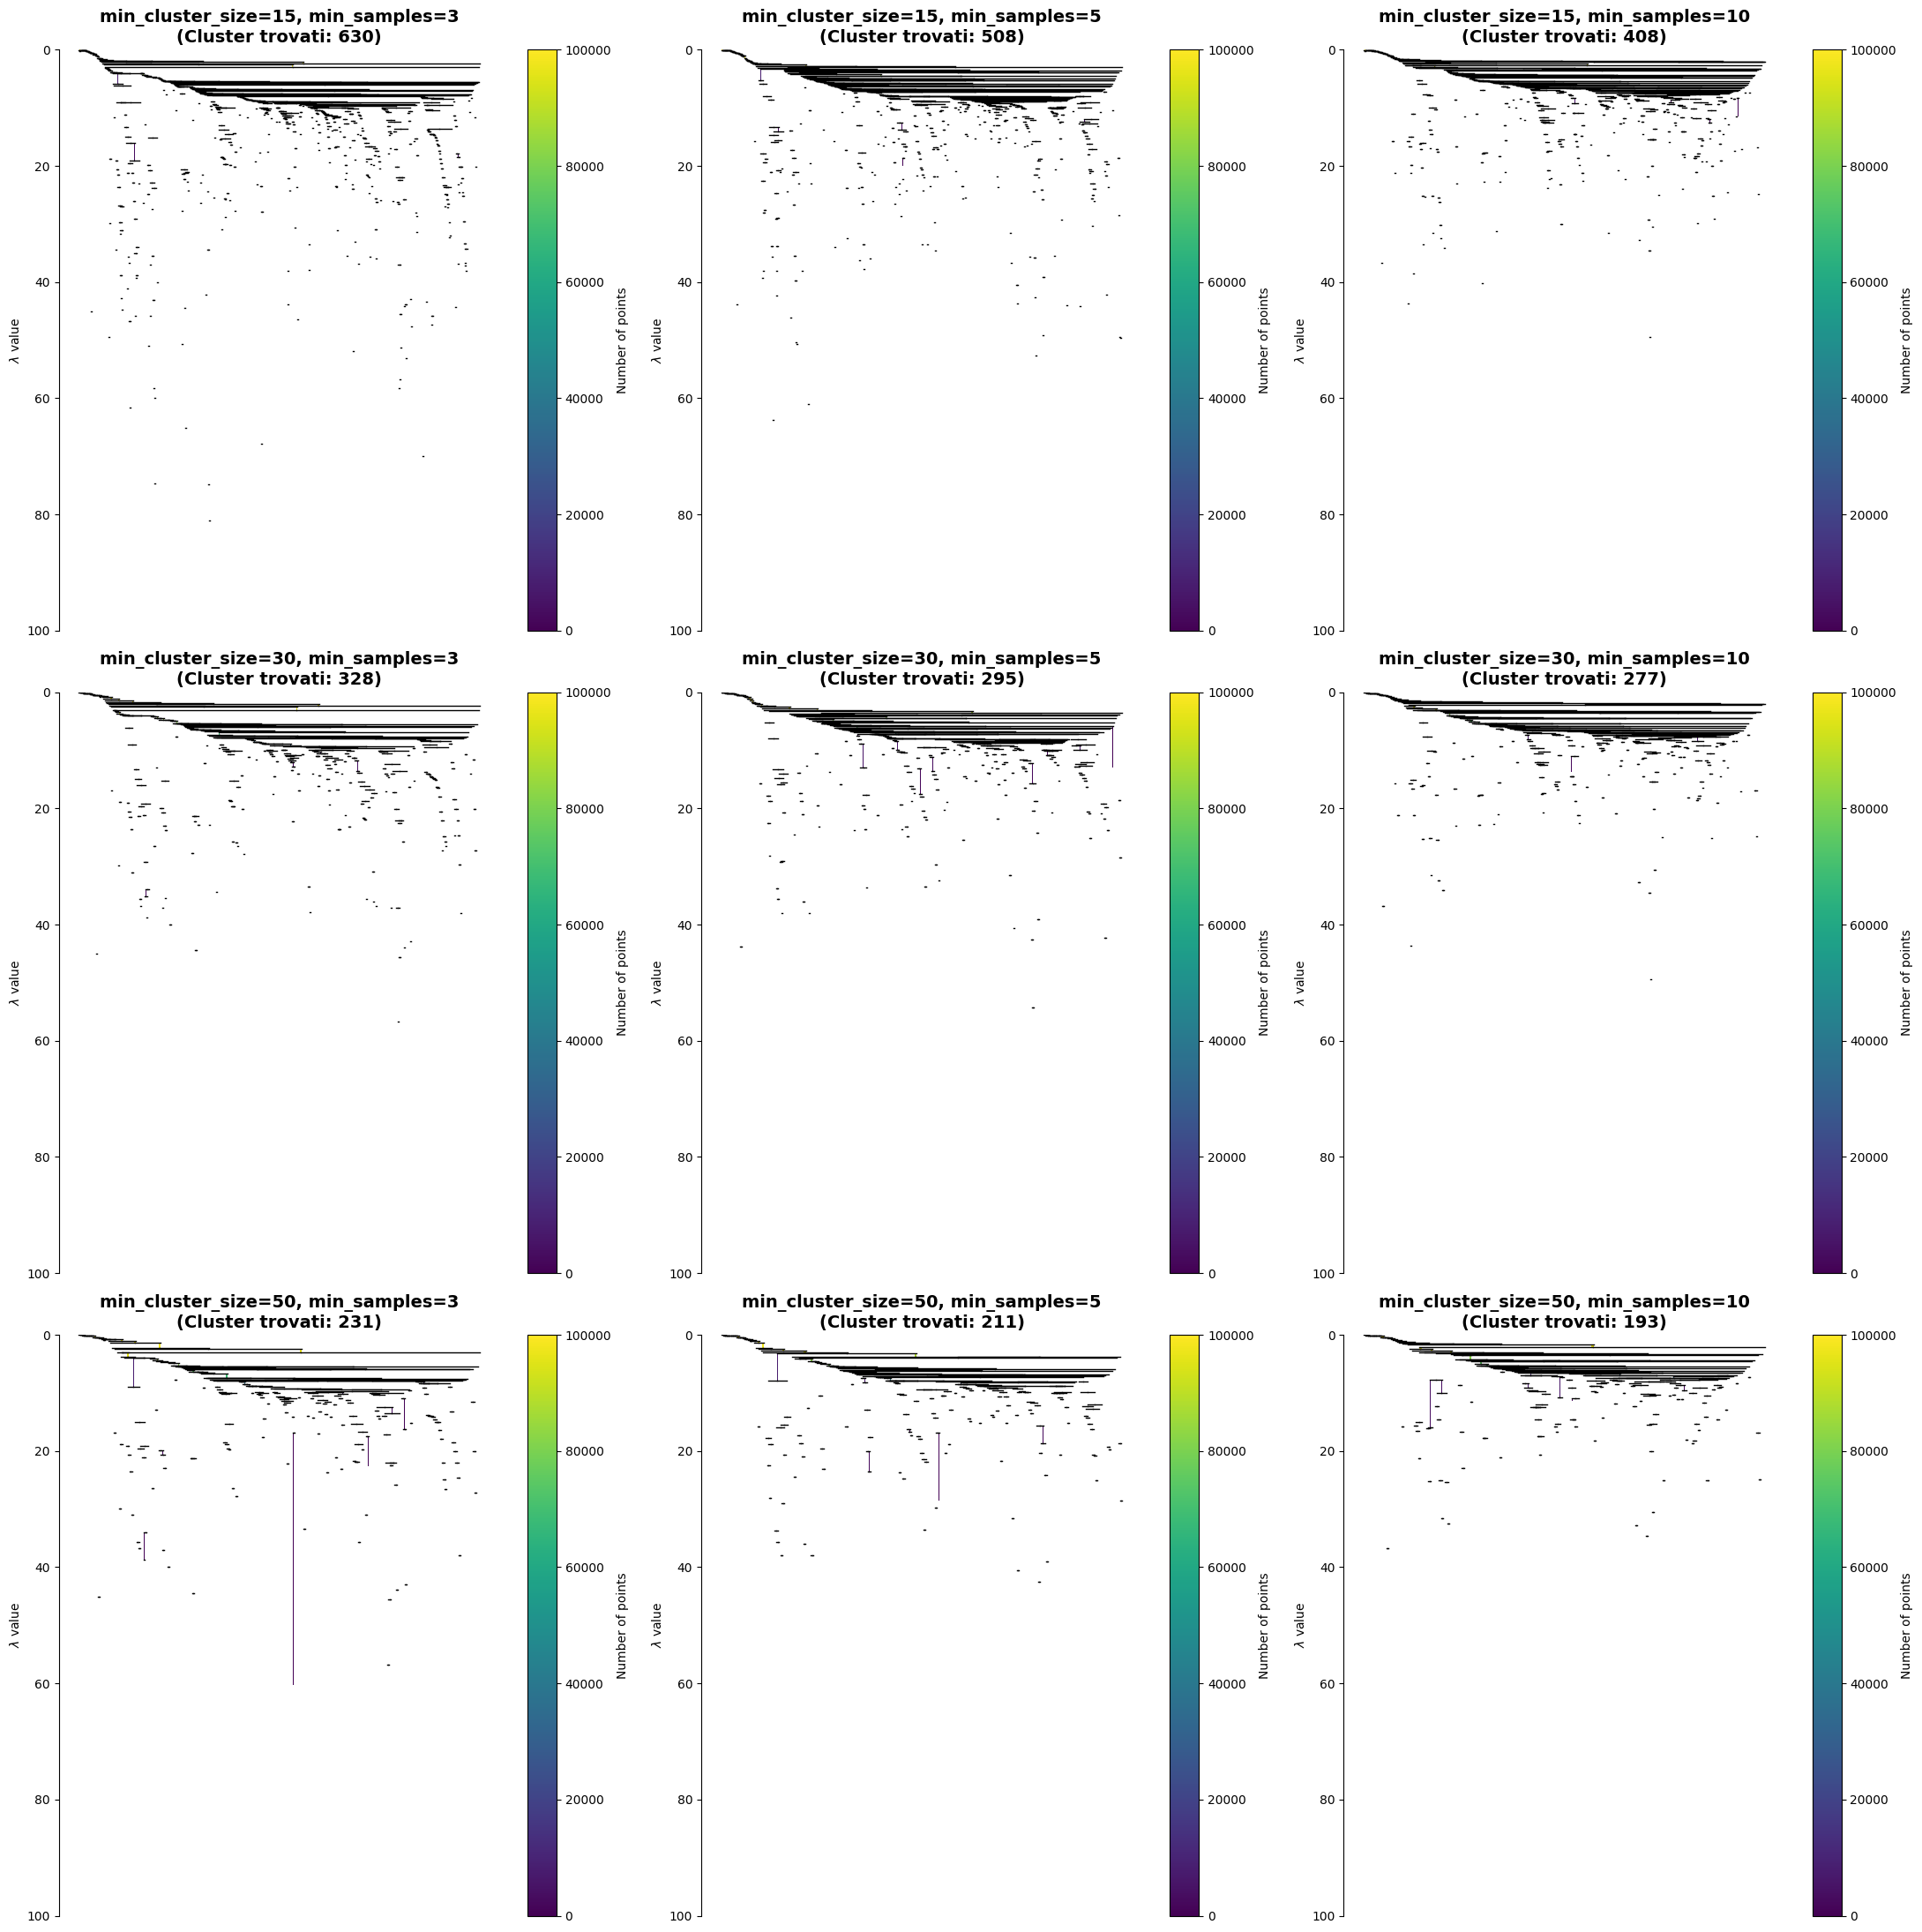

In [11]:
sample_size = 100000
np.random.seed(42)

if reduced_embeddings.shape[0] > sample_size:
    indices = np.random.choice(reduced_embeddings.shape[0], sample_size, replace=False)
    test_data = reduced_embeddings[indices]
else:
    test_data = reduced_embeddings

# Jitter potenziato a 0.01 per abbattere definitivamente il picco dei Lambda
test_data = test_data + np.random.normal(0, 0.01, test_data.shape)

min_cluster_sizes = [15, 30, 50]
min_samples_list = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(22, 22))
print("Avvio Hyperparameter Sweep. Generazione di 9 alberi di densità in corso...")

for i, mcs in enumerate(min_cluster_sizes):
    for j, ms in enumerate(min_samples_list):
        temp_clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='leaf',
            core_dist_n_jobs=-1
        ).fit(test_data)
        
        ax = axes[i, j]
        n_clusters = len(set(temp_clusterer.labels_)) - (1 if -1 in temp_clusterer.labels_ else 0)
        hex_palette = sns.color_palette("husl", n_clusters).as_hex()
        
        try:
            # Ora che abbiamo salvato l'asse Y, possiamo riaccendere i colori!
            temp_clusterer.condensed_tree_.plot(
                select_clusters=False,
                selection_palette=hex_palette,
                axis=ax
            )
        except Exception as e:
            ax.text(0.5, 0.5, "Nessun Cluster Trovato o Errore", ha='center', va='center')
            
        ax.set_title(f"min_cluster_size={mcs}, min_samples={ms}\n(Cluster trovati: {n_clusters})", fontsize=14, fontweight='bold')
        ax.set_ylim(100,0)

plt.tight_layout()
plt.show()


## 5. Salvataggio Risultati
Prepariamo il dataframe finale per LLM.

In [6]:
index_df["cluster_id"] = labels
index_df["cluster_probability"] = probabilities

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Cluster totali: {n_clusters}")
print(f"Punti scartati come rumore: {n_noise} ({(n_noise/len(labels))*100:.2f}%)")

output_path = OUTPUT_DIR / "jmail_emails_clustered.parquet"
index_df.to_parquet(output_path, index=False)
print(f"Dati salvati in: {output_path}")

Cluster totali: 920
Punti scartati come rumore: 1284817 (73.10%)
Dati salvati in: /home/filippo/Scrivania/pizza-cluster/data/processed/jmail_emails_clustered.parquet


In [ ]:

print("Calcolo dei 900 Centroidi in corso...")
# Trova tutti i cluster validi (escludendo -1 che è il rumore)
unique_clusters = [c for c in np.unique(labels) if c != -1]
centroids = []

for c in unique_clusters:
    # Calcoliamo il centro esatto (media spaziale) di ogni cluster
    cluster_points = reduced_embeddings[labels == c]
    centroids.append(cluster_points.mean(axis=0))

centroids = np.array(centroids)
print(f"Trovati {len(centroids)} Centroidi. Inizio Overlapping...")

top_n = 10
batch_size = 50000
all_top_clusters = []
all_top_probs = []

for i in range(0, len(reduced_embeddings), batch_size):
    print(f"Elaborazione Batch da {i} a {min(i+batch_size, len(reduced_embeddings))}...")
    batch_data = reduced_embeddings[i:i+batch_size]
    
    # Calcolo velocissimo della distanza di ogni email verso TUTTI i 900 centri
    distances = cdist(batch_data, centroids, metric='sqeuclidean')
    
    # Convertiamo le distanze in "Probabilità di Overlap" usando la Softmax!
    # Il parametro / 0.5 (Temperatura) serve per sgranare le probabilità 
    soft_probs = softmax(-distances / 0.5, axis=1)
    
    # Estraiamo la Top 10 matematica
    top_indices = np.argsort(soft_probs, axis=1)[:, -top_n:][:, ::-1]
    top_values = np.take_along_axis(soft_probs, top_indices, axis=1)
    
    # Mappiamo le posizioni back ai veri ID dei cluster
    mapped_clusters = np.array(unique_clusters)[top_indices]
    
    all_top_clusters.extend(mapped_clusters.tolist())
    all_top_probs.extend(top_values.tolist())

# Creiamo le due nuove preziose colonne
index_df["top_10_clusters"] = all_top_clusters
index_df["top_10_probs"] = all_top_probs

# Salviamo in un NUOVO FILE senza toccare quello di prima!
output_path_soft = OUTPUT_DIR / "jmail_emails_clustered_soft.parquet"
index_df.to_parquet(output_path_soft, index=False)

print(f"\nFINITO! I nuovi risultati overlapping sono salvati al sicuro in:\n{output_path_soft}")


Calcolo dei 900 Centroidi in corso...
Trovati 920 Centroidi. Inizio Overlapping...
Elaborazione Batch da 0 a 50000...
Elaborazione Batch da 50000 a 100000...
Elaborazione Batch da 100000 a 150000...
Elaborazione Batch da 150000 a 200000...
Elaborazione Batch da 200000 a 250000...
Elaborazione Batch da 250000 a 300000...
Elaborazione Batch da 300000 a 350000...
Elaborazione Batch da 350000 a 400000...
Elaborazione Batch da 400000 a 450000...
Elaborazione Batch da 450000 a 500000...
Elaborazione Batch da 500000 a 550000...
Elaborazione Batch da 550000 a 600000...
Elaborazione Batch da 600000 a 650000...
Elaborazione Batch da 650000 a 700000...
Elaborazione Batch da 700000 a 750000...
Elaborazione Batch da 750000 a 800000...
Elaborazione Batch da 800000 a 850000...
Elaborazione Batch da 850000 a 900000...
Elaborazione Batch da 900000 a 950000...
Elaborazione Batch da 950000 a 1000000...
Elaborazione Batch da 1000000 a 1050000...
Elaborazione Batch da 1050000 a 1100000...
Elaborazione Batc

In [ ]:
# Carichiamo il file con il Soft Clustering appena calcolato
output_path_soft = OUTPUT_DIR / "jmail_emails_clustered_soft.parquet"
df_soft = pd.read_parquet(output_path_soft)

# Cerchiamo 5 email ambigue (dove l'algoritmo classico era insicuro, es. fiducia sotto al 50%)
df_ambigue = df_soft[(df_soft['cluster_id'] != -1) & (df_soft['cluster_probability'] < 0.50)].sample(5, random_state=42)

print("=== CONFRONTO HARD vs SOFT CLUSTERING (Email Ambigue) ===\n")
for idx, row in df_ambigue.iterrows():
    print(f"VECCHIO METODO (Hard): Forzata SOLO al Cluster {row['cluster_id']} (Fiducia: {row['cluster_probability']*100:.1f}%)")
    
    # Stampiamo la nuova sfaccettatura Overlapping
    print("NUOVO METODO (Overlapping Top 3):")
    top_clusters = row['top_10_clusters']
    top_probs = row['top_10_probs']
    
    for i in range(3): # Mostriamo la Top 3
        if top_probs[i] > 0.01: # Mostriamo solo se c'è almeno l'1% di affinità
            print(f"  -> {top_probs[i]*100:.1f}% di affinità col Cluster {top_clusters[i]}")
    print("-" * 50)


=== CONFRONTO HARD vs SOFT CLUSTERING (Email Ambigue) ===

VECCHIO METODO (Hard): Forzata SOLO al Cluster 157 (Fiducia: 12.9%)
NUOVO METODO (Overlapping Top 3):
  -> 9.2% di affinità col Cluster 157
  -> 8.8% di affinità col Cluster 258
  -> 5.5% di affinità col Cluster 431
--------------------------------------------------
VECCHIO METODO (Hard): Forzata SOLO al Cluster 195 (Fiducia: 13.6%)
NUOVO METODO (Overlapping Top 3):
  -> 6.2% di affinità col Cluster 195
  -> 5.9% di affinità col Cluster 199
  -> 5.8% di affinità col Cluster 170
--------------------------------------------------
VECCHIO METODO (Hard): Forzata SOLO al Cluster 8 (Fiducia: 5.5%)
NUOVO METODO (Overlapping Top 3):
  -> 100.0% di affinità col Cluster 8
--------------------------------------------------
VECCHIO METODO (Hard): Forzata SOLO al Cluster 560 (Fiducia: 42.2%)
NUOVO METODO (Overlapping Top 3):
  -> 7.4% di affinità col Cluster 560
  -> 7.3% di affinità col Cluster 559
  -> 7.1% di affinità col Cluster 557
---

Estrazione delle email 'ponte' dal dataset...
Costruzione Grafo: 168 Cluster connessi tramite 120 ponti.


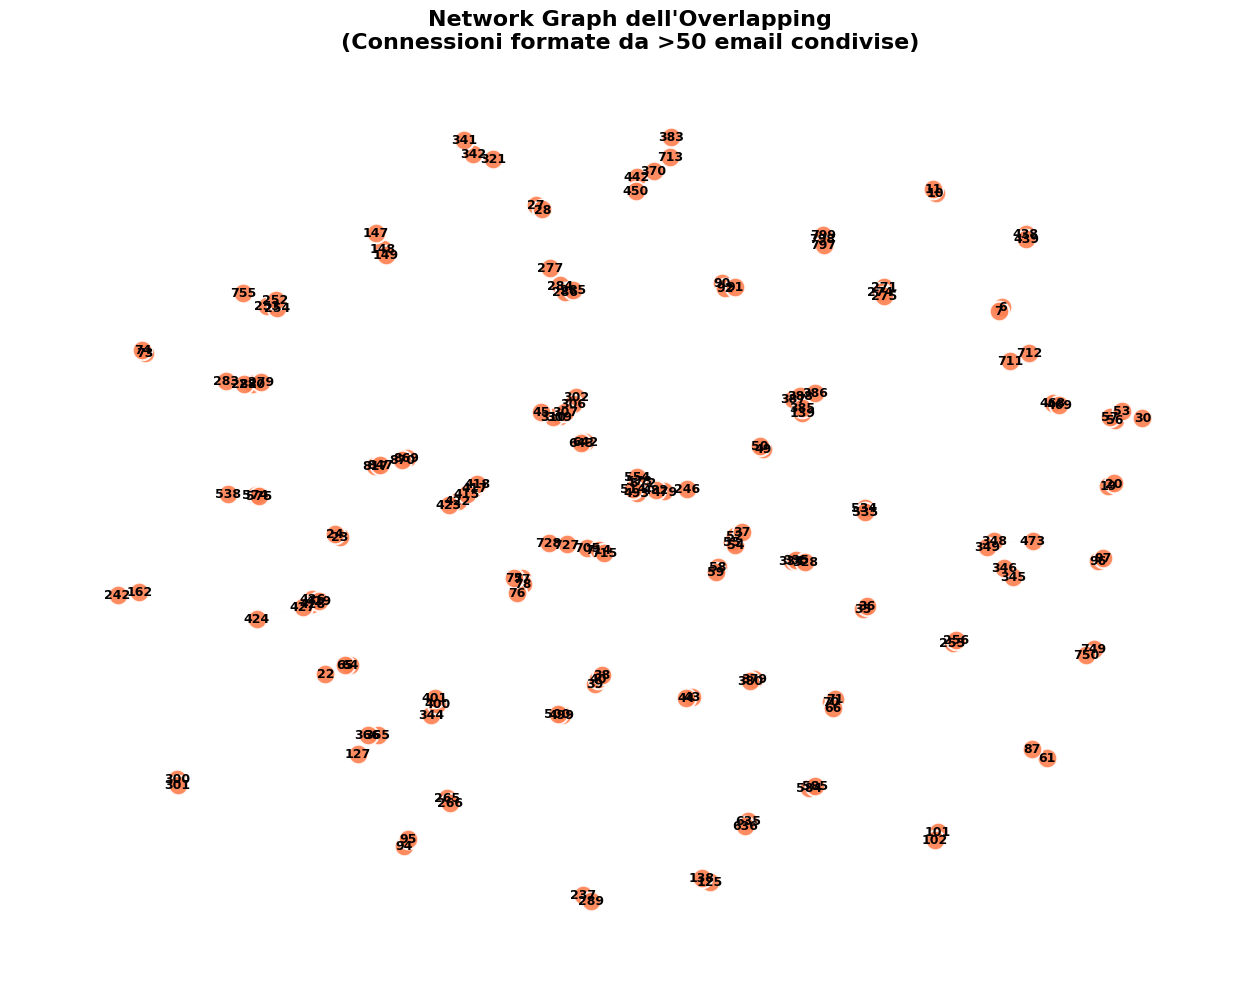

In [ ]:

print("Estrazione delle email 'ponte' dal dataset...")
df = pd.read_parquet(OUTPUT_DIR / "jmail_emails_clustered_soft.parquet")

# Estraiamo i primi due cluster per ogni email e la percentuale del secondo
top1 = np.array([x[0] for x in df['top_10_clusters']])
top2 = np.array([x[1] for x in df['top_10_clusters']])
prob2 = np.array([x[1] for x in df['top_10_probs']])

# Consideriamo valide solo le email in cui il "secondo classificato" ha almeno il 10% di probabilità
valid = prob2 > 0.10
top1_valid = top1[valid]
top2_valid = top2[valid]

edges = {}
for c1, c2 in zip(top1_valid, top2_valid):
    pair = tuple(sorted([c1, c2]))
    edges[pair] = edges.get(pair, 0) + 1

# Inizializziamo il grafo vuoto
G = nx.Graph()

# Aggiungiamo solo i ponti forti (minimo 50 email condivise) per non creare un groviglio nero illegibile
MIN_SHARED_EMAILS = 50
for (c1, c2), weight in edges.items():
    if weight >= MIN_SHARED_EMAILS:
        G.add_edge(c1, c2, weight=weight)

print(f"Costruzione Grafo: {G.number_of_nodes()} Cluster connessi tramite {G.number_of_edges()} ponti.")

plt.figure(figsize=(16, 12))
plt.title(f"Network Graph dell'Overlapping\n(Connessioni formate da >{MIN_SHARED_EMAILS} email condivise)", fontsize=16, fontweight='bold')

# Posizionamento spaziale: il layout "Spring" spinge i cluster più legati a stare vicini
pos = nx.spring_layout(G, k=0.4, seed=42)

# Calcolo dello spessore dei cavi in base al numero di email condivise
weights = [G[u][v]['weight'] for u, v in G.edges()]
if weights:
    normalized_weights = [(w / max(weights)) * 8 for w in weights]
else:
    normalized_weights = [1]

# Disegno di nodi, archi ed etichette
nx.draw_networkx_nodes(G, pos, node_size=200, node_color='coral', alpha=0.9, edgecolors='white', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=normalized_weights, edge_color='gray', alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='black')

plt.axis('off')
plt.show()
